Used: https://quantum.cloud.ibm.com/docs/en/tutorials/hello-world

Figure 3: Circuit for Swap test: https://arxiv.org/pdf/2003.09187

For returning data: Qiskit provides 2 ways
- you can obtain a probability distribution for a set of qubits you choose to measure
- or you can obtain the expectation value of an observable

In our case, we wanna get the Fidelity.
$$
\text{Fidelity} = F
= \left|\langle \psi \mid \phi \rangle\right|^2
= 2P(0) - 1
$$

$$
\text{Expectation value} = \langle Z \rangle
= P(0) - P(1)
= 2P(0) - 1
= F
$$

So we wanna measure the q0 and get the expectation value, which is our fidelity.

Running on the simulator for now, so using FakeBelemV2 for now 

## Simplest setup: 2 train points, 1 test points, 1 dimension:

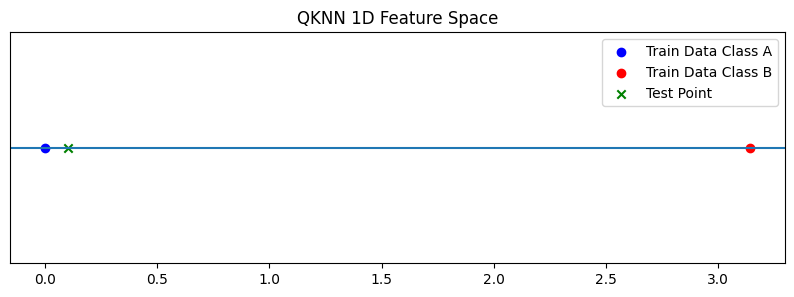

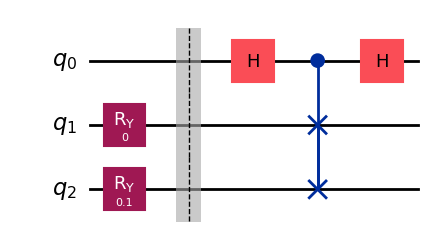

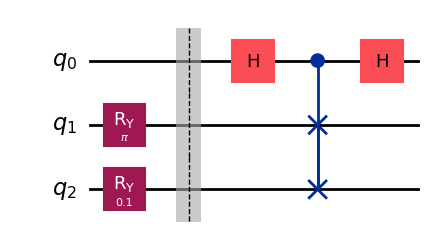

Fidelity Train 1 (Pi): 0.9974
Fidelity Train 2 (0):  0.0148
Prediction: Class A


In [1]:
from qiskit import QuantumCircuit
from qiskit.quantum_info import SparsePauliOp
from qiskit.transpiler import generate_preset_pass_manager
from qiskit_ibm_runtime import EstimatorV2 as Estimator
from qiskit_ibm_runtime.fake_provider import FakeBelemV2
import numpy as np
from IPython.display import display
import matplotlib.pyplot as plt

train_points = [0, np.pi]
test_point = 0.1

plt.figure(figsize=(10, 3))
plt.axhline(0)
plt.scatter(train_points[0], 0, c='blue', label='Train Data Class A')
plt.scatter(train_points[1], 0, c='red', label='Train Data Class B')
plt.scatter(test_point, 0, c='green', marker='x', label='Test Point')
plt.title("QKNN 1D Feature Space")
plt.legend()
plt.yticks([]) # Hide Y axis
plt.show()

backend = FakeBelemV2()
pm = generate_preset_pass_manager(backend=backend, optimization_level=1)
observable = SparsePauliOp("IIZ") # Measure q0

def fidelity(train_val, test_val):
    qc = QuantumCircuit(3)
    
    # 1. Encoding
    qc.ry(train_val, 1)
    qc.ry(test_val, 2)
    qc.barrier()
    
    # 2. SWAP Test
    qc.h(0)
    qc.cswap(0, 1, 2)
    qc.h(0)

    display(qc.draw("mpl"))

    isa = pm.run(qc)
    obs = observable.apply_layout(isa.layout)
    estimator = Estimator(backend)
    job = estimator.run([(isa, obs)], precision=0.01)
    result = job.result()

    return result[0].data.evs

fid1 = fidelity(train_points[0], test_point)
fid2 = fidelity(train_points[1], test_point)

print(f"Fidelity Train 1 (Pi): {fid1:.4f}")
print(f"Fidelity Train 2 (0):  {fid2:.4f}")

label = "Class A" if fid1 > fid2 else "Class B"
print(f"Prediction: {label}")

In [2]:
no_train_points = 2
no_test_points = 1
no_dimensions = 1